# Cluster-and-propagate dialect ID -- a fifth, independent method

A cheap **semi-supervised** approach: cluster sentence embeddings
unsupervised (K-Means, k=100 per script group), hand-label only the
single point closest to each cluster's centroid (200 labels total
instead of 15,999), then propagate that one label to every other point
in the same cluster. Tests whether K-Means clusters in this embedding
space line up with dialect/language well enough that 200 real labels can
stand in for thousands.

**Genuinely independent of every other method's labels** -- clustering
never looks at `train.jsonl`'s existing (Qwen-generated) `label` field,
only at raw text. The existing labeled dataset is used **only in Phase
2, only to evaluate** the propagated labels once real, human, are
supplied -- never to build or seed the clusters, and never modified.

**Pipeline**:
1. **Phase 1** (this session, run now): script-gate `train.jsonl` into
   `arabic`/`latin` groups (same convention as every other method here,
   `code_switch`/`other` excluded by construction -- "ignore
   code-switched examples"), embed each row (tokenize -> average token
   embeddings, frozen `CBOWAttention`), K-Means (`k=100`, `k-means++`
   init) per group, find the training point nearest each centroid, export
   the 200 prototypes for manual annotation.
2. **Human annotation** (separate step, via the published webpage): you
   label each of the 200 prototypes with its dialect/language --
   restricted to that prototype's own script group's classes (2-way for
   `arabic`, 3-way for `latin`), same structural restriction the rest of
   this project relies on.
3. **Phase 2** (rerun this notebook once `data/cluster_annotations.json`
   exists): propagate each prototype's label to its whole cluster, assign
   every `test.jsonl` row to its nearest **train-fitted** centroid (no
   leakage), evaluate the propagated label against `test.jsonl`'s real
   label.

Run this notebook's kernel from the GPU venv (`ai-gpu`).


In [1]:
import json
import sys
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, adjusted_rand_score

ROOT = Path.cwd().resolve().parents[1]  # project root, when running from Dialect_Identification/notebooks/
DATA_DIR = ROOT / "Dialect_Identification" / "data"
MODELS_DIR = ROOT / "Dialect_Identification" / "models"
WORD2VEC_ATTENTION_DIR = ROOT / "Embeddings" / "word2vec_attention"

sys.path.insert(0, str(WORD2VEC_ATTENTION_DIR / "scripts"))
sys.path.insert(0, str(ROOT / "Tokenization"))
from model import CBOWAttention  # noqa: E402
from tokenizer_utils import load_tokenizer  # noqa: E402

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")  # embedding lookups only -- GPU not needed


## 1. Script-gating (same convention as every other method here)

In [2]:
import re

_MENTION_WITH_FRAGMENT_RE = re.compile(r"\[MENTION\](\s*-[^\s]{1,10})?")
_URL_RE = re.compile(r"\[URL\]")
_INLINE_WHITESPACE_RE = re.compile(r"[ \t]+")
_ARABIC_RE = re.compile(r"[\u0600-\u06ff\u0750-\u077f\u08a0-\u08ff\ufb50-\ufdff\ufe70-\ufeff]")
_LATIN_RE = re.compile(r"[a-zA-Z\u00c0-\u024f]")

ARABIC_CLASSES = ["msa", "darija"]
LATIN_CLASSES = ["arabize", "french", "english"]
GROUP_CLASSES = {"arabic": ARABIC_CLASSES, "latin": LATIN_CLASSES}

MAX_CHARS = 500  # same truncation convention as label_dataset.py's MAX_PROMPT_CHARS


def clean_for_classification(text: str) -> str:
    text = _MENTION_WITH_FRAGMENT_RE.sub("", text)
    text = _URL_RE.sub("", text)
    return _INLINE_WHITESPACE_RE.sub(" ", text).strip()


def script_of(text: str) -> str:
    has_ar = bool(_ARABIC_RE.search(text))
    has_lat = bool(_LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


## 2. Load the frozen embedder + build sentence embeddings

**"Tokenize sentences, embed tokens, average"** -- literally
`input_embeddings[tok.encode(text)].mean(axis=0)`, no per-word
averaging step (unlike the word-level `get_word_vector` used elsewhere
in this project) and no attention/context block -- a plain embedding
average, per spec.

In [3]:
meta = json.loads((WORD2VEC_ATTENTION_DIR / "data" / "meta.json").read_text(encoding="utf-8"))
tok = load_tokenizer(meta["tokenizer"]["key"], meta["tokenizer"]["vocab_size"])
vocab_size = meta["tokenizer"]["vocab_size_actual"]
PAD_ID = 0

checkpoints = sorted(
    (WORD2VEC_ATTENTION_DIR / "models").glob("checkpoint_step*.pt"),
    key=lambda p: int(p.stem.split("step")[-1]),
)
CHECKPOINT = checkpoints[-1]
ckpt = torch.load(CHECKPOINT, map_location=device)
ckpt_args = ckpt["args"]

embedder = CBOWAttention(
    vocab_size=vocab_size, embed_dim=ckpt_args["embed_dim"],
    num_heads=ckpt_args["num_heads"], ff_dim=ckpt_args["ff_dim"],
).to(device)
embedder.load_state_dict(ckpt["model_state_dict"])
embedder.eval()

EMBED_DIM = ckpt_args["embed_dim"]
embedding_matrix = embedder.input_embeddings.weight.detach().cpu().numpy()
print(f"Loaded checkpoint step={ckpt['step']:,} ({CHECKPOINT.name}), embed_dim={EMBED_DIM}")


def sentence_embedding(text: str) -> np.ndarray:
    ids = [i for i in tok.encode(text[:MAX_CHARS]) if i != PAD_ID and i < vocab_size]
    if not ids:
        return np.zeros(EMBED_DIM, dtype=np.float32)
    return embedding_matrix[ids].mean(axis=0)


Loaded checkpoint step=675,000 (checkpoint_step675000.pt), embed_dim=128


## 3. Load + embed `train.jsonl`, script-gated

`label` is read here **only** to compute the diagnostic "expected
purity" in the next section -- never used to build or seed the clusters
themselves (K-Means sees embeddings only).

In [4]:
def load_group_rows(split: str, group: str) -> list[dict]:
    rows = []
    with (DATA_DIR / f"{split}.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            r = json.loads(line)
            cleaned = clean_for_classification(r["text"])
            if script_of(cleaned) != group:
                continue  # excludes code_switch (mixed) and other -- "ignore code-switched examples"
            rows.append({"id": r["id"], "text": r["text"], "label": r["label"]})
    return rows


group_data = {}
for group in ("arabic", "latin"):
    train_rows = load_group_rows("train", group)
    embeddings = np.stack([sentence_embedding(r["text"]) for r in train_rows])
    group_data[group] = {"rows": train_rows, "embeddings": embeddings}
    print(f"{group}: {len(train_rows):,} train rows embedded ({embeddings.shape})")


arabic: 6,660 train rows embedded ((6660, 128))


latin: 4,563 train rows embedded ((4563, 128))


## 4. K-Means (k=100/group, k-means++ init) + nearest-to-centroid prototype selection

`init="k-means++"` (sklearn's default, and the "good initialization
method" spec) spreads initial centroids apart by distance rather than
picking them uniformly at random, which is what actually makes k=100
converge to reasonable, non-degenerate clusters instead of some sitting
empty. `n_init=10` reruns the whole fit from 10 different k-means++
seeds and keeps the best (lowest inertia) -- standard practice, K-Means
is only a local optimum from any single seed.

In [5]:
K = 100

for group, gd in group_data.items():
    kmeans = KMeans(n_clusters=K, init="k-means++", n_init=10, random_state=SEED)
    cluster_ids = kmeans.fit_predict(gd["embeddings"])
    gd["kmeans"] = kmeans
    gd["cluster_ids"] = cluster_ids

    # Nearest training point to each cluster's centroid, by the same
    # (Euclidean) metric K-Means itself uses.
    prototypes = []
    for c in range(K):
        member_idx = np.where(cluster_ids == c)[0]
        if len(member_idx) == 0:
            continue  # possible but rare with k-means++ init; skip empty clusters
        dists = np.linalg.norm(gd["embeddings"][member_idx] - kmeans.cluster_centers_[c], axis=1)
        nearest = member_idx[dists.argmin()]
        prototypes.append({"cluster_id": int(c), "row_idx": int(nearest), "cluster_size": int(len(member_idx))})
    gd["prototypes"] = prototypes
    print(f"{group}: {len(prototypes)} non-empty clusters (of {K}), "
          f"cluster sizes min={min(p['cluster_size'] for p in prototypes)} "
          f"max={max(p['cluster_size'] for p in prototypes)} "
          f"mean={np.mean([p['cluster_size'] for p in prototypes]):.1f}")


arabic: 100 non-empty clusters (of 100), cluster sizes min=1 max=347 mean=66.6


latin: 100 non-empty clusters (of 100), cluster sizes min=1 max=364 mean=45.6


## 5. Diagnostic: expected cluster purity (using the *existing* Qwen labels, not for clustering)

Same "verify the assumption before trusting it" check as the
`word_cluster/` baseline's purity sweep -- computed from `train.jsonl`'s
already-existing labels, purely as a preview of how good label
propagation is *likely* to be once real human labels replace the
prototype placeholder. Not used anywhere in the clustering or
propagation itself.

In [6]:
for group, gd in group_data.items():
    classes = GROUP_CLASSES[group]
    class_to_id = {c: i for i, c in enumerate(classes)}
    true_ids = np.array([class_to_id[r["label"]] for r in gd["rows"]])
    ari = adjusted_rand_score(true_ids, gd["cluster_ids"])

    purities = []
    for c in range(K):
        member_idx = np.where(gd["cluster_ids"] == c)[0]
        if len(member_idx) == 0:
            continue
        counts = np.bincount(true_ids[member_idx], minlength=len(classes))
        purities.append(counts.max() / counts.sum())
    weighted_purity = np.average(purities, weights=[
        (gd["cluster_ids"] == c).sum() for c in range(K) if (gd["cluster_ids"] == c).sum() > 0
    ])
    chance = 1.0 / len(classes)
    print(f"{group}: weighted cluster purity={weighted_purity:.3f} (chance={chance:.3f}), "
          f"ARI(cluster vs true label)={ari:.3f}")


arabic: weighted cluster purity=0.795 (chance=0.500), ARI(cluster vs true label)=0.013
latin: weighted cluster purity=0.831 (chance=0.333), ARI(cluster vs true label)=0.052


## 6. Export prototypes for the annotation webpage

In [7]:
prototype_export = []
for group, gd in group_data.items():
    for p in gd["prototypes"]:
        row = gd["rows"][p["row_idx"]]
        prototype_export.append({
            "id": row["id"],
            "group": group,
            "cluster_id": p["cluster_id"],
            "cluster_size": p["cluster_size"],
            "text": row["text"],
            "allowed_classes": GROUP_CLASSES[group],
        })

PROTOTYPES_PATH = DATA_DIR / "cluster_prototypes.json"
PROTOTYPES_PATH.write_text(json.dumps(prototype_export, ensure_ascii=False, indent=1), encoding="utf-8")
print(f"Wrote {len(prototype_export)} prototypes to {PROTOTYPES_PATH}")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
with (MODELS_DIR / "cluster_lid.pkl").open("wb") as f:
    pickle.dump({
        "kmeans": {g: gd["kmeans"] for g, gd in group_data.items()},
        "checkpoint_used": str(CHECKPOINT),
        "k": K,
    }, f)
print(f"Saved fitted K-Means models to {MODELS_DIR / 'cluster_lid.pkl'}")


Wrote 200 prototypes to C:\Users\ASUS\Desktop\summer 2026\Darija\Dialect_Identification\data\cluster_prototypes.json
Saved fitted K-Means models to C:\Users\ASUS\Desktop\summer 2026\Darija\Dialect_Identification\models\cluster_lid.pkl


---
## Phase 2 -- propagate + evaluate (run after human annotation)

Everything below checks for `data/cluster_annotations.json` first and
exits gracefully if it isn't there yet, so this notebook can be executed
top-to-bottom right now (Phase 1 completes for real, Phase 2 prints a
"waiting" message) and **re-executed later** once annotation is done, at
which point Phase 2 runs for real too.

In [8]:
ANNOTATIONS_PATH = DATA_DIR / "cluster_annotations.json"
HAS_ANNOTATIONS = ANNOTATIONS_PATH.exists()

if HAS_ANNOTATIONS:
    annotations = json.loads(ANNOTATIONS_PATH.read_text(encoding="utf-8"))
    # {prototype_id: label}
    n_labeled = sum(1 for v in annotations.values() if v)
    print(f"Loaded {n_labeled}/{len(prototype_export)} human annotations from {ANNOTATIONS_PATH}")
else:
    print(f"{ANNOTATIONS_PATH} not found yet -- Phase 2 will skip. "
          f"Label the 200 prototypes via the annotation webpage, then have Claude fetch and save "
          f"them here, and rerun this notebook.")


Loaded 200/200 human annotations from C:\Users\ASUS\Desktop\summer 2026\Darija\Dialect_Identification\data\cluster_annotations.json


### 7. Propagate: cluster -> majority-vote label (from whatever prototypes were actually labeled)

A cluster's label is the annotated label of its own prototype; if a
prototype was left unlabeled (skipped), that cluster has no label and is
excluded from evaluation rather than guessed at.

In [9]:
if HAS_ANNOTATIONS:
    cluster_labels = {}  # (group, cluster_id) -> label
    for group, gd in group_data.items():
        for p in gd["prototypes"]:
            row = gd["rows"][p["row_idx"]]
            label = annotations.get(row["id"])
            if label:
                cluster_labels[(group, p["cluster_id"])] = label
    print(f"{len(cluster_labels)}/{sum(len(gd['prototypes']) for gd in group_data.values())} clusters have a usable label")
else:
    print("skipped (no annotations)")


200/200 clusters have a usable label


### 8. Evaluate on `test.jsonl` (held out, never used for clustering or prototype selection)

Each test row is embedded the same way and assigned to its **nearest
train-fitted centroid** (`kmeans.predict`, no refitting) -- that
cluster's propagated label is the prediction, compared against
`test.jsonl`'s real (Qwen-generated) label. Rows whose nearest cluster
has no usable label (prototype was skipped) are excluded from accuracy,
counted separately.

In [10]:
if HAS_ANNOTATIONS:
    for group, gd in group_data.items():
        classes = GROUP_CLASSES[group]
        test_rows = load_group_rows("test", group)
        test_embeddings = np.stack([sentence_embedding(r["text"]) for r in test_rows])
        pred_cluster_ids = gd["kmeans"].predict(test_embeddings)

        y_true, y_pred, unlabeled_count = [], [], 0
        for row, c in zip(test_rows, pred_cluster_ids):
            label = cluster_labels.get((group, int(c)))
            if label is None:
                unlabeled_count += 1
                continue
            y_true.append(row["label"])
            y_pred.append(label)

        acc = accuracy_score(y_true, y_pred) if y_true else float("nan")
        print(f"\n{group}: accuracy={acc:.4f} ({sum(t == p for t, p in zip(y_true, y_pred))}/{len(y_true)}), "
              f"{unlabeled_count} test rows fell in an unlabeled cluster (excluded)")

        print("Per-class accuracy:")
        for cname in classes:
            idx = [i for i, t in enumerate(y_true) if t == cname]
            n_correct = sum(y_pred[i] == cname for i in idx)
            print(f"  {cname:<10} {n_correct:>4}/{len(idx):<4} acc={n_correct / len(idx) if idx else float('nan'):.3f}")
else:
    print("skipped (no annotations)")



arabic: accuracy=0.7009 (1167/1665), 0 test rows fell in an unlabeled cluster (excluded)
Per-class accuracy:
  msa         460/542  acc=0.849
  darija      707/1123 acc=0.630



latin: accuracy=0.8100 (925/1142), 0 test rows fell in an unlabeled cluster (excluded)
Per-class accuracy:
  arabize     566/621  acc=0.911
  french      331/415  acc=0.798
  english      28/106  acc=0.264


### 9. Cluster-size distribution (sanity check on k=100's granularity)

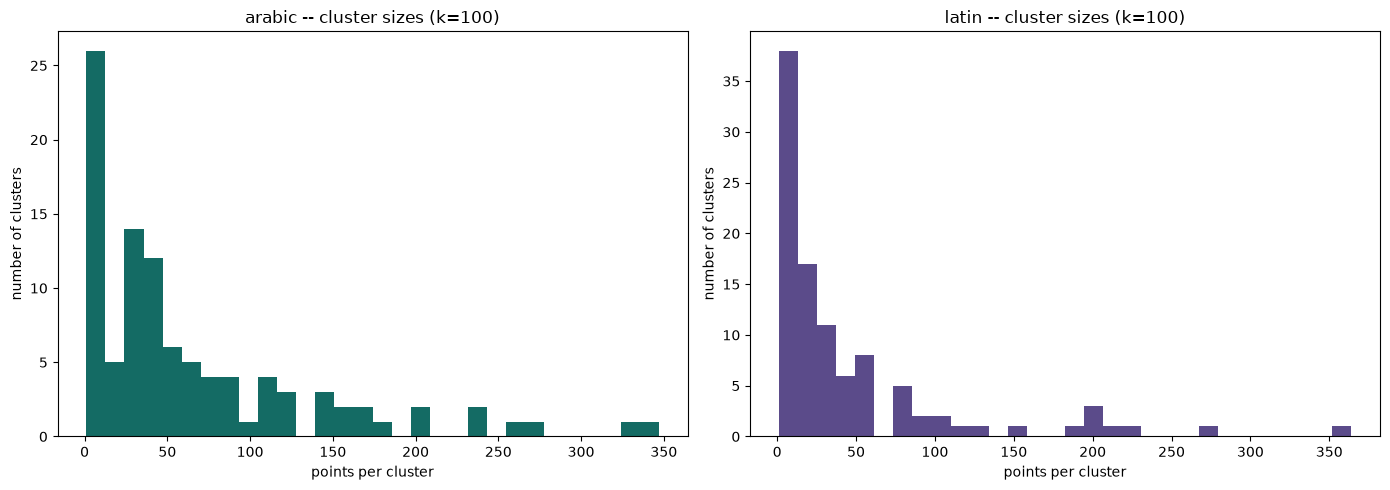

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (group, gd) in zip(axes, group_data.items()):
    sizes = [p["cluster_size"] for p in gd["prototypes"]]
    ax.hist(sizes, bins=30, color="#146B64" if group == "arabic" else "#5B4B8A")
    ax.set_title(f"{group} -- cluster sizes (k={K})")
    ax.set_xlabel("points per cluster")
    ax.set_ylabel("number of clusters")
plt.tight_layout()
plt.show()
